## Ejercicio 2


Construyendo arquitectura de la red...
Capa construida: 2 entradas --> 10 neuronas
Capa construida: 10 entradas --> 1 neuronas

Iniciando entrenamiento...


Entrenamiento: 100%|██████████| 500/500 [00:29<00:00, 16.91it/s]


Fin del entrenamiento (Límite de épocas). Errores finales: 31

Prueba con datos nuevos:
Resultado Test: 970/1000 correctos (97.0% de precisión)

Generando grafico de convergencia...


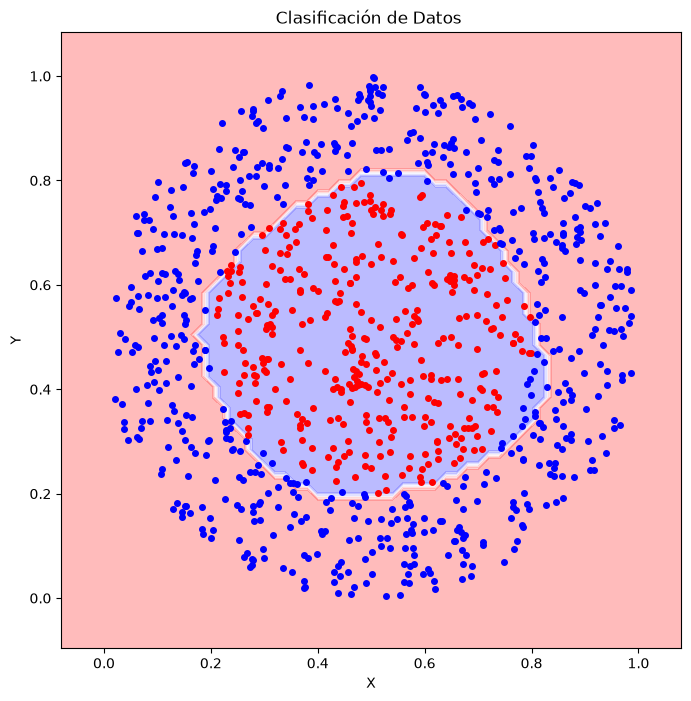

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import csv

class Capa:
    def __init__(self, num_entradas, num_neuronas):
        self.w = np.random.uniform(-0.5, 0.5, (num_entradas+1, num_neuronas))
        
        # Variables para guardar memoria durante el Forward y usarla en el Backward
        self.entrada = None
        self.salida = None

    def activacion_sigmoide(self, z):
        return (1.0 - np.exp(-z)) / (1.0 + np.exp(-z))
        
    def derivada_sigmoide(self, a):
        return 0.5 * (1.0 - a**2)

    def forward(self, entrada): 
        sesgo = np.array([[-1]])
        self.entrada = np.hstack((sesgo, entrada))
        # Potencial de activación: v = x*w
        v = np.dot(self.entrada, self.w)
        self.salida = self.activacion_sigmoide(v)
        return self.salida

    def backward(self, gradiente_siguiente, tasa_aprendizaje): # HACIA ATRAS
        delta = gradiente_siguiente * self.derivada_sigmoide(self.salida)
        gradiente_hacia_atras = np.dot(delta, self.w[1:, :].T)
        self.w += tasa_aprendizaje * np.dot(self.entrada.T, delta)
        return gradiente_hacia_atras

class RedMulticapa:
    def __init__(self, arquitectura, tasa_aprendizaje=0.1, epocas_maximas=1000, tolerancia_error=0.0):
        self.capas = [] 
        self.tasa_aprendizaje = tasa_aprendizaje
        self.epocas_maximas = epocas_maximas
        self.tolerancia_error = tolerancia_error

        # --- CONSTRUCCION DE LAS CAPAS ---
        for i in range(len(arquitectura) - 1):
            entradas_capa = arquitectura[i]
            neuronas_capa = arquitectura[i+1]
            
            nueva_capa = Capa(entradas_capa, neuronas_capa)
            self.capas.append(nueva_capa)
            
            print(f"Capa construida: {entradas_capa} entradas --> {neuronas_capa} neuronas")

    def forward_red(self, x):
            salida = x.reshape(1, -1)
            for capa in self.capas:
                salida = capa.forward(salida)
            return salida
    
    def train(self, X_train, Y_train):
        max_errores = len(Y_train) * self.tolerancia_error

        for epoca in tqdm(range(self.epocas_maximas), desc="Entrenamiento: "):
            errores_epoca = 0 
            # mezclamos los datos
            indices = np.random.permutation(len(X_train))
            X_permut = X_train[indices]
            Y_permut = Y_train[indices]

            for x, yd in zip(X_permut, Y_permut):
                
                yd_matriz = np.array([[yd]])
                salida_actual = self.forward_red(x)

                # salida bipolar, validación de umbral
                y_calculado = 1 if salida_actual[0][0] >= 0.0 else -1
                
                if y_calculado != yd:
                    errores_epoca += 1

                # Backward
                gradiente = yd_matriz - salida_actual
                for capa in reversed(self.capas):
                    gradiente = capa.backward(gradiente, self.tasa_aprendizaje)

            if errores_epoca <= max_errores:
                print(f"Convergencia alcanzada en la época {epoca + 1}")
                return
                
        print(f"Fin del entrenamiento (Límite de épocas). Errores finales: {errores_epoca}")

    def test(self, X_test, Y_test):
            aciertos = 0
            for x, yd in zip(X_test, Y_test):
                salida = self.forward_red(x)
                y_calculado = 1 if salida[0][0] >= 0.0 else -1
                if y_calculado == yd:
                    aciertos += 1
    
            precision = (aciertos / len(Y_test))* 100.0
            
            print(f"Resultado Test: {aciertos}/{len(Y_test)} correctos ({precision:.1f}% de precisión)")
            return precision

def cargar_datos(ruta_archivo):
    datos_x = []
    yd = []
    with open(ruta_archivo, 'r') as archivo:
        archivo_csv = csv.reader(archivo)
        for fila in archivo_csv:
            entradas = [float(val) for val in fila[:-1]]
            datos_x.append(entradas)
            # Conserva estrictamente -1 y 1
            yd.append(int(float(fila[-1])))
            
    return np.array(datos_x), np.array(yd)

def graficar_frontera(red, X, Y, titulo):
    # Definimos los limites del grafico 
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    
    # Creamos una grilla de puntos muy juntitos (cada 0.02)
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
    
    # Aplanamos la grilla para pasarla por la red como si fueran datos de entrada
    grilla = np.c_[xx.ravel(), yy.ravel()]
    
    Z = []
    for punto in grilla:
        salida = red.forward_red(punto)
        # Aplicamos el mismo umbral que usamos en train y test
        clase = 1 if salida[0][0] >= 0.0 else -1
        Z.append(clase)
        
    # Convertimos la lista a numpy array y le devolvemos la forma de la grilla original
    Z = np.array(Z).reshape(xx.shape)
    
    # Pintamos el fondo según la clase (-1 o 1) 
    plt.figure(figsize=(8, 8))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.bwr) # Colores azul y rojo
    
    # Dibujamos los puntos reales por encima
    for i in range(len(Y)):
        if Y[i] == 1:
            plt.plot(X[i, 0], X[i, 1], 'bo', markersize=4) # Azul para clase 1
        else:
            plt.plot(X[i, 0], X[i, 1], 'ro', markersize=4) # Rojo para clase -1
            
    plt.title(titulo)
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.show()

if __name__ == "__main__":
    X_trn, Y_trn = cargar_datos("datos/concent_trn.csv")
    X_tst, Y_tst = cargar_datos("datos/concent_tst.csv")
    
    print("\nConstruyendo arquitectura de la red...")
    # Aumentamos las neuronas en la capa oculta a 10 para poder cerrar el circulo
    red = RedMulticapa(arquitectura=[2, 10, 1], tasa_aprendizaje=0.01, epocas_maximas=500)
    
    print("\nIniciando entrenamiento...")
    red.train(X_trn, Y_trn)
    
    print("\nPrueba con datos nuevos:")
    red.test(X_tst, Y_tst)
    
    print("\nGenerando grafico de convergencia...")
    graficar_frontera(red, X_tst, Y_tst, "Clasificación de Datos ")

